In [1]:
import pandas as pd
import numpy as np

In [24]:
import matplotlib.pyplot as plt

In [31]:
import pickle
import swifter

In [2]:
path = '../data/us_10m_nointernship_ai_skills_body.parquet.gzip'

In [3]:
path[-3:]

'zip'

In [4]:
if path[-3:] == 'csv:':
    usdf = pd.read_csv(path)
elif path[-3:] == 'zip':
    usdf = pd.read_parquet(path)

In [5]:
usdf.rename(columns = {'Has AI Skills': 'AI ROLE'}, inplace = True)

In [31]:
pd.set_option('display.max_columns', None)

In [32]:
usdf

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,False,False,False,True
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,False,True,False,True,False,False,False,False
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,False,True,False,False,False,False,False,False
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,False,False,False
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P...","[\n ""Capital Requirements"",\n ""Insurance Pro...",2021-03-08,2023-12-14,41-3021.00,Insurance Sales Agents,41-3021.00,Insurance Sales A

# Experience

In [6]:
# Define buckets for years of experience
bins = [-2, -1, 0, 2, 5, 10, 20, 100]
labels = ['Missing', '0 years', '1-2 years', '3-5 years', '6-10 years', '11-20 years', '21+ years']


In [7]:
usdf['EXPERIENCE_BUCKET'] = pd.cut(usdf['MIN_YEARS_EXPERIENCE'], bins=bins, labels=labels, right=True)

In [8]:
usdf['EXPERIENCE_BUCKET']=usdf['EXPERIENCE_BUCKET'].astype(str)

In [9]:
# replace nan with 'None Listed'
usdf['EXPERIENCE_BUCKET'] = usdf['EXPERIENCE_BUCKET'].replace('nan', 'None Listed')

In [10]:
usdf['EXPERIENCE_BUCKET'].value_counts(dropna=False)

EXPERIENCE_BUCKET
None Listed    6323300
1-2 years      2368551
3-5 years      1801781
6-10 years      611543
0 years         398468
11-20 years      77683
Name: count, dtype: int64

In [38]:
usdf.head()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,False,False,False,True,3-5 years
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,False,True,False,True,False,False,False,False,6-10 years
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,False,True,False,False,False,False,False,False,None Listed
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,False,False,False,3-5 years
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,False,False,False,1-2 years


In [39]:
if path[-3:] == 'csv:':
    usdf.to_csv(path)
elif path[-3:] == 'zip':
    usdf.to_parquet(path)

# Salary

In [12]:
salaries = pd.read_csv('../data/SALARIES.csv')

In [13]:
all_data = usdf.merge(salaries, left_on='ID', right_on='ID', how='left')

In [18]:
usdf = all_data

In [20]:
all_data.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'LEAVE', 'HEALTH_WELLBEING',
       'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET', 'SALARY',
       'LOG_SALARY'],
      dtype='object')

In [27]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'LEAVE', 'HEALTH_WELLBEING',
       'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET', 'SALARY',
       'LOG_SALARY'],
      dtype='object')

In [40]:
usdf['SALARY']

0        194350.0
1        135075.0
2         70962.0
3        117050.0
4         90000.0
           ...   
19995     41600.0
19996     38250.0
19997     24284.0
19998     37960.0
19999    115000.0
Name: SALARY, Length: 20000, dtype: float64

In [41]:
usdf[usdf['SALARY']>=0]

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,False,False,False,True,3-5 years
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,False,True,False,True,False,False,False,False,6-10 years
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,False,True,False,False,False,False,False,False,None Listed
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,False,False,False,3-5 years
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,False,False,False,1-2 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P...","[\n ""Capital Requirements"",\n ""Insurance Pro...",2021-03-0

<Axes: >

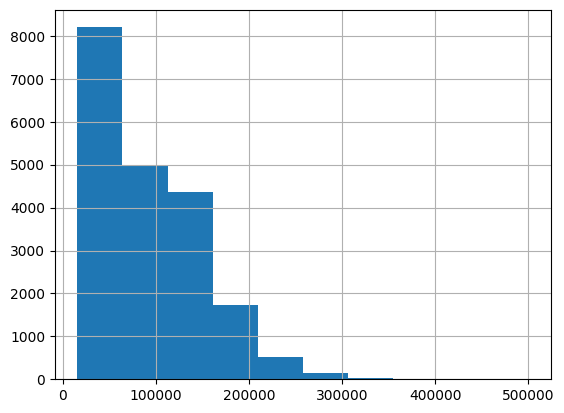

In [42]:
usdf['SALARY'].hist()

In [16]:
usdf['LOG_SALARY'] = np.log(usdf['SALARY'])

<Axes: >

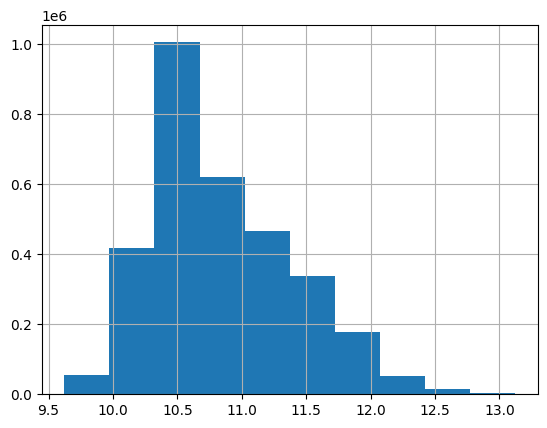

In [25]:
usdf['LOG_SALARY'].hist()

In [26]:
if path[-3:] == 'csv:':
    usdf.to_csv(path)
elif path[-3:] == 'zip':
    usdf.to_parquet(path)

In [33]:

ai_na = usdf[usdf['AI ROLE'].isna()]
print("Number of NAs: ", len(ai_na))
print("loading skill IDs")
# Classify Jobs With AI Skills
with open('../data/ai_skill_ids.pkl', 'rb') as f:
    ai_skill_ids = pickle.load(f)
ai_skill_ids
# Function to check if any AI skill ID is in the job's skills
def has_ai_skills(skill_list, ai_skill_ids):
    skill_list = eval(skill_list)  # Convert string representation of list to actual list
    return any(skill_id in skill_list for skill_id in ai_skill_ids)
ai_na['AI ROLE'] = ai_na.swifter.progress_bar(True).apply(lambda x: has_ai_skills(x['SKILLS'], ai_skill_ids), axis=1)

usdf.loc[ai_na.index, 'AI ROLE'] = ai_na['AI ROLE']



Number of NAs:  1637310
loading skill IDs


Pandas Apply:   0%|          | 0/1637310 [00:00<?, ?it/s]

/tmp/ipykernel_3843428/1965338994.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_na['AI ROLE'] = ai_na.swifter.progress_bar(True).apply(lambda x: has_ai_skills(x['SKILLS'], ai_skill_ids), axis=1)


In [34]:
ai_na = usdf[usdf['AI ROLE'].isna()]
len(ai_na)

0

In [36]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'LEAVE', 'HEALTH_WELLBEING',
       'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET', 'SALARY',
       'LOG_SALARY'],
      dtype='object')

In [39]:
# look at skills of an AI ROLE in 2018
for i, row in usdf[(usdf['AI ROLE']==True) & (usdf['YEAR']==2018)].head(10).iterrows():
    print(row['SKILLS_NAME'])

[
  "Power BI",
  "Information Technology",
  "Management",
  "Apache Hadoop",
  "Data Modeling",
  "Application Services",
  "Agile Methodology",
  "Digital Marketing",
  "Application Development",
  "Business Intelligence Reporting",
  "Statistical Inference",
  "Forecasting",
  "Big Data",
  "Statistical Modeling",
  "Self Service Technologies",
  "Business Valuation",
  "Algorithms",
  "Systems Analysis",
  "Python (Programming Language)",
  "Apache Spark",
  "Dashboard",
  "Analytics",
  "Supply Chain",
  "Data Analysis",
  "Machine Learning",
  "Business Requirements",
  "Management Information Systems",
  "Key Performance Indicators (KPIs)",
  "Financial Controls",
  "Design Thinking",
  "Scripting",
  "Test Design",
  "DevOps",
  "Data Integrity",
  "Innovation",
  "Advanced Analytics",
  "SQL (Programming Language)",
  "Apache Hive",
  "Tableau (Business Intelligence Software)",
  "Computer Science",
  "R (Programming Language)"
]
[
  "Subsystems",
  "Pattern Recognition",
  "

In [41]:
usdf.to_parquet('../data/us_10m_nointernship_ai_skills_body.parquet.gzip', compression='gzip')

In [42]:
# export usdf without body
usdf.drop(columns=['BODY']).to_parquet('../data/us_10m_nointernship_ai_skills_benefits.parquet.gzip', compression='gzip')